# Case DconData — Distribuidora de Alimentos Funcionais e Suplementos
## Material analítico — Consultor de Análise de Dados

**Autor:** Gabriel Garcia

Este notebook documenta o raciocínio completo por trás do diagnóstico e das
recomendações apresentadas no material executivo (`Case_Distribuidora_Diagnostico.pptx`).

**Recorte escolhido:** conectar o **diagnóstico agregado** (crescimento x
rentabilidade x capacidade operacional) com a **segmentação** de canal de
aquisição, cliente e produto — para transformar o achado em recomendação
priorizável, não genérica.

**Estrutura deste notebook:**
1. Carga e inspeção inicial dos dados
2. Qualidade de dados — nulos, inconsistências e tratamentos
3. Bloco 1 — Diagnóstico agregado (crescimento, rentabilidade, operação)
4. Bloco 2 — Segmentação (canal de aquisição, produto/estoque)
5. Bloco 3 — Fonte pública (BACEN) como apoio à leitura de custo
6. Síntese e recomendações

> Uso de IA: usei o Claude (Anthropic) como copiloto de análise ao longo de
> todo o processo — para explorar as bases, sugerir hipóteses e depurar código.
> Todos os números, filtros e conclusões deste notebook foram conferidos por
> mim rodando o código e inspecionando os resultados linha a linha. Onde a IA
> errou (ex.: uma hipótese inicial sobre os nulos de câmbio) o erro foi
> identificado por validação cruzada com os dados reais e corrigido — ver
> seção 2.4.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 10

NAVY = "#1E2761"
ACCENT = "#E8734A"
GRAY = "#6B7280"
GOOD = "#3E8E5A"


## 1. Carga e inspeção inicial

Os dados representam extrações de 4 sistemas diferentes (comercial/clientes,
produtos/estoque, marketing, operação), com granularidades distintas. Vamos
carregar tudo primeiro e entender o formato de cada base antes de qualquer
tratamento.


In [2]:
pedidos    = pd.read_csv('pedidos.csv', parse_dates=['data_pedido','data_prometida','data_expedicao'])
itens      = pd.read_csv('itens_pedidos.csv')
clientes   = pd.read_csv('clientes.csv', parse_dates=['data_cadastro'])
produtos   = pd.read_csv('produtos.csv')
estoque    = pd.read_csv('estoque.csv', parse_dates=['data_referencia','data_validade'])
compras    = pd.read_csv('compras.csv', parse_dates=['data_pedido_compra','data_prevista','data_recebimento','data_evento_cambio'])
marketing  = pd.read_csv('marketing.csv', parse_dates=['data'])
operacao   = pd.read_csv('operacao.csv', parse_dates=['data_operacao'])
capacidade = pd.read_csv('capacidade.csv', parse_dates=['data'])
devolucoes = pd.read_csv('devolucoes.csv', parse_dates=['data_solicitacao'])

bases = {
    'pedidos': pedidos, 'itens_pedidos': itens, 'clientes': clientes, 'produtos': produtos,
    'estoque': estoque, 'compras': compras, 'marketing': marketing, 'operacao': operacao,
    'capacidade': capacidade, 'devolucoes': devolucoes,
}
for nome, df in bases.items():
    print(f"{nome:15s} shape={df.shape}")


pedidos         shape=(15776, 19)
itens_pedidos   shape=(43088, 7)
clientes        shape=(4520, 10)
produtos        shape=(180, 13)
estoque         shape=(30017, 12)
compras         shape=(720, 16)
marketing       shape=(810, 12)
operacao        shape=(15161, 15)
capacidade      shape=(780, 9)
devolucoes      shape=(650, 10)


In [3]:
# Janela temporal coberta pelos dados
print("Pedidos:   ", pedidos.data_pedido.min().date(), "a", pedidos.data_pedido.max().date())
print("Marketing: ", marketing.data.min().date(), "a", marketing.data.max().date())
print("Operação:  ", operacao.data_operacao.min().date(), "a", operacao.data_operacao.max().date())


Pedidos:    2025-01-01 a 2026-06-30
Marketing:  2025-01-01 a 2026-06-29
Operação:   2025-01-02 a 2026-06-30


## 2. Qualidade de dados — nulos, inconsistências e tratamentos

Antes de qualquer análise, mapeamos os problemas reais de qualidade nos dados
e decidimos um tratamento para cada um — documentando a premissa.


### 2.1 Categoria de produto com grafia divergente

In [4]:
print(produtos.categoria.value_counts(dropna=False))


categoria
Proteínas e recuperação       41
Performance                   35
Vitaminas e minerais          32
Alimentos funcionais          29
Snacks e barras               24
Bebidas e consumo imediato    16
NaN                            2
Proteínas & recuperação        1
Name: count, dtype: int64


In [5]:
# Tratamento: normalizar grafia divergente para o padrão mais frequente
produtos['categoria'] = produtos['categoria'].replace(
    {'Proteínas & recuperação': 'Proteínas e recuperação'}
)
print("Após tratamento:")
print(produtos.categoria.value_counts(dropna=False))


Após tratamento:
categoria
Proteínas e recuperação       42
Performance                   35
Vitaminas e minerais          32
Alimentos funcionais          29
Snacks e barras               24
Bebidas e consumo imediato    16
NaN                            2
Name: count, dtype: int64


### 2.2 Itens de pedido sem custo histórico

`custo_unitario_historico` é o custo do produto na época da venda — necessário
para calcular margem de contribuição real. Vamos ver a extensão do problema e
se existe um fallback razoável.


In [6]:
nulos_custo = itens[itens.custo_unitario_historico.isna()]
print(f"Itens sem custo histórico: {len(nulos_custo)} ({len(nulos_custo)/len(itens)*100:.2f}% do total)")
print(f"Produtos distintos afetados: {nulos_custo.produto_id.nunique()}")

produtos_afetados = produtos[produtos.produto_id.isin(nulos_custo.produto_id.unique())]
print(f"Desses, {produtos_afetados.custo_atual.notna().sum()} de {len(produtos_afetados)} têm custo_atual preenchido — usável como fallback")


Itens sem custo histórico: 248 (0.58% do total)
Produtos distintos afetados: 92
Desses, 92 de 92 têm custo_atual preenchido — usável como fallback


In [7]:
# Tratamento: preencher custo histórico ausente com custo_atual do produto,
# sinalizando quais linhas foram estimadas (não é o custo real da época da venda)
custo_map = produtos.set_index('produto_id')['custo_atual']
itens['custo_estimado'] = itens['custo_unitario_historico'].isna()
itens['custo_unitario_tratado'] = itens['custo_unitario_historico'].fillna(
    itens['produto_id'].map(custo_map)
)
print("Nulos restantes após tratamento:", itens['custo_unitario_tratado'].isna().sum())


Nulos restantes após tratamento: 0


### 2.3 Cancelamentos e devoluções — taxas de referência

Registramos as taxas para contexto, mas sem concentração anômala que mude o
recorte da análise.


In [8]:
print("Status dos pedidos:")
print(pedidos.status.value_counts(normalize=True).mul(100).round(2))
print()
print("Motivo de devolução:")
print(devolucoes.motivo.value_counts(normalize=True).mul(100).round(2))


Status dos pedidos:
status
CONCLUÍDO            91.98
DEVOLVIDO_PARCIAL     4.12
CANCELADO             3.90
Name: proportion, dtype: float64

Motivo de devolução:
motivo
AVARIA               21.10
PRODUTO INCORRETO    20.79
ARREPENDIMENTO       20.31
VALIDADE             19.69
QUALIDADE            18.11
Name: proportion, dtype: float64


### 2.4 Câmbio em `compras.csv` — cuidado com a leitura rápida dos nulos

Numa primeira passada, `taxa_cambio_interna` tem 593 valores nulos, o que
parece um problema grande de qualidade de dado. **Mas isso é enganoso** —
câmbio só se aplica a compras importadas. Precisamos checar a distribuição
por `origem_fornecedor` antes de decidir qualquer tratamento.


In [9]:
print("Nulos em taxa_cambio_interna, por origem do fornecedor:")
print(compras.groupby('origem_fornecedor')['taxa_cambio_interna'].apply(lambda x: x.isna().sum()))


Nulos em taxa_cambio_interna, por origem do fornecedor:
origem_fornecedor
IMPORTADO      1
NACIONAL     592
Name: taxa_cambio_interna, dtype: int64


**Conclusão:** dos 593 nulos, **592 são compras nacionais — nulo é o
comportamento esperado**, câmbio não se aplica. Apenas **1 registro
importado** realmente tinha o dado faltando. Esse único caso é tratado na
Seção 5, usando a taxa PTAX oficial do Banco Central como fonte pública.


## 3. Bloco 1 — Diagnóstico agregado

### 3.1 Crescimento com margem cedida

Olhamos receita bruta, desconto (% da receita) e frete por mês, considerando
apenas pedidos concluídos.


In [10]:
pedidos['mes'] = pedidos.data_pedido.dt.to_period('M')
conc = pedidos[pedidos.status == 'CONCLUÍDO'].copy()

receita_mensal = conc.groupby('mes').agg(
    pedidos=('pedido_id', 'count'),
    receita_bruta=('valor_bruto_produtos', 'sum'),
    desconto_itens=('desconto_itens', 'sum'),
    desconto_pedido=('desconto_pedido', 'sum'),
    frete_pago=('frete_pago', 'sum'),
    frete_cobrado=('frete_cobrado', 'sum'),
).reset_index()

receita_mensal['desc_pct'] = ((receita_mensal.desconto_itens + receita_mensal.desconto_pedido)
                               / receita_mensal.receita_bruta * 100)
receita_mensal['subsidio_frete'] = receita_mensal.frete_pago - receita_mensal.frete_cobrado
receita_mensal['ticket_medio'] = receita_mensal.receita_bruta / receita_mensal.pedidos

receita_mensal[['mes','pedidos','receita_bruta','desc_pct','subsidio_frete','ticket_medio']].round(1)


/tmp/ipykernel_738/860384109.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  pedidos['mes'] = pedidos.data_pedido.dt.to_period('M')
/tmp/ipykernel_738/860384109.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  receita_mensal[['mes','pedidos','receita_bruta','desc_pct','subsidio_frete','ticket_medio']].round(1)


,mes,pedidos,receita_bruta,desc_pct,subsidio_frete,ticket_medio
0,2025-01,689,501843.1,13.8,13117.7,728.4
1,2025-02,683,493176.6,13.8,12738.5,722.1
2,2025-03,678,499688.9,14.1,12827.9,737.0
3,2025-04,693,495508.9,13.5,12651.8,715.0
4,2025-05,684,459041.3,13.5,12526.6,671.1
5,2025-06,685,494678.5,13.5,12525.2,722.2
6,2025-07,754,536964.3,13.6,13644.7,712.2
7,2025-08,743,531011.1,13.6,13652.9,714.7
8,2025-09,748,481271.9,13.5,13541.3,643.4
9,2025-10,753,502204.3,13.4,13936.0,666.9


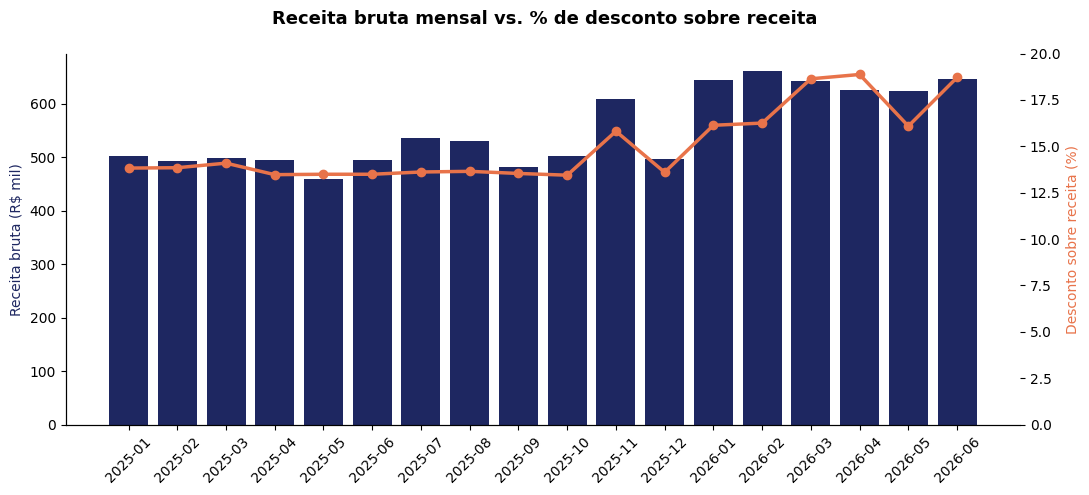

In [11]:
fig, ax1 = plt.subplots(figsize=(11, 5))
x = receita_mensal.mes.astype(str)
ax1.bar(x, receita_mensal.receita_bruta/1000, color=NAVY, label='Receita bruta (R$ mil)')
ax1.set_ylabel('Receita bruta (R$ mil)', color=NAVY)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(x, receita_mensal.desc_pct, color=ACCENT, marker='o', linewidth=2.5, label='Desconto (%)')
ax2.set_ylabel('Desconto sobre receita (%)', color=ACCENT)
ax2.set_ylim(0, 20)

fig.suptitle('Receita bruta mensal vs. % de desconto sobre receita', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()


**Leitura:** a partir de nov/25 (pico sazonal) e consolidando em jan/26, o
volume de pedidos sobe de forma consistente — mas o desconto sobre receita
salta de ~13,5% para 16-19%. O crescimento de volume vem acompanhado de
margem cedida, não é "gratuito".


### 3.2 Custo de aquisição (CAC) por plataforma

In [12]:
marketing['mes'] = marketing.data.dt.to_period('M')
marketing['periodo'] = marketing.mes.apply(lambda p: '2025' if p.year == 2025 else '2026 (jan-jun)')

cac_plataforma = marketing.groupby(['periodo', 'plataforma']).agg(
    investimento=('investimento', 'sum'),
    novos_clientes=('novos_clientes_atribuidos', 'sum'),
    receita_atribuida=('receita_atribuida', 'sum'),
    meses=('mes', 'nunique'),
).reset_index()

cac_plataforma['investimento_mes'] = (cac_plataforma.investimento / cac_plataforma.meses).round(0)
cac_plataforma['cac'] = (cac_plataforma.investimento / cac_plataforma.novos_clientes).round(1)
cac_plataforma['roas'] = (cac_plataforma.receita_atribuida / cac_plataforma.investimento).round(2)

cac_plataforma[['periodo','plataforma','investimento_mes','cac','roas']].sort_values(['plataforma','periodo'])


,periodo,plataforma,investimento_mes,cac,roas
0,2025,Creators,2145.0,122.0,5.37
3,2026 (jan-jun),Creators,4956.0,152.5,4.27
1,2025,Google Ads,2782.0,90.0,12.23
4,2026 (jan-jun),Google Ads,3844.0,112.5,10.94
2,2025,Meta Ads,2744.0,74.0,11.17
5,2026 (jan-jun),Meta Ads,4440.0,92.5,10.89


**Leitura:** o investimento mensal em mídia quase dobra entre 2025 e 2026 em
todas as plataformas — mas o **CAC sobe e o ROAS cai em todas elas**. O canal
Influenciador (Creators), que já era o mais caro e o de menor ROAS em 2025,
foi o que mais recebeu aumento proporcional de verba.


In [13]:
cac_2025 = marketing[marketing.periodo=='2025'].groupby('plataforma').investimento.sum() / marketing[marketing.periodo=='2025'].mes.nunique()
cac_2026 = marketing[marketing.periodo!='2025'].groupby('plataforma').investimento.sum() / marketing[marketing.periodo!='2025'].mes.nunique()
variacao = ((cac_2026 - cac_2025) / cac_2025 * 100).round(1)
print("Variação de investimento mensal médio, 2025 -> 2026 (%):")
print(variacao.sort_values(ascending=False))


Variação de investimento mensal médio, 2025 -> 2026 (%):
plataforma
Creators      131.0
Meta Ads       61.8
Google Ads     38.1
Name: investimento, dtype: float64


### 3.3 Operação sem escalar: SLA e horas extras

In [14]:
operacao['mes'] = operacao.data_operacao.dt.to_period('M')
sla_mensal = operacao.groupby('mes').agg(
    sla=('expedido_no_prazo', 'mean'),
    retrabalho=('retrabalho', 'mean'),
    ruptura=('ruptura_ou_substituicao', 'mean'),
).reset_index()
sla_mensal[['sla','retrabalho','ruptura']] = (sla_mensal[['sla','retrabalho','ruptura']] * 100).round(1)

capacidade['mes'] = capacidade.data.dt.to_period('M')
cap_mensal = capacidade.groupby('mes').agg(
    horas_extras=('horas_extras', 'sum'),
    horas_disponiveis=('horas_regulares_disponiveis', 'sum'),
    pessoas_planejadas=('pessoas_planejadas', 'mean'),
).reset_index()
cap_mensal['pct_hora_extra'] = (cap_mensal.horas_extras / cap_mensal.horas_disponiveis * 100).round(1)

op_full = sla_mensal.merge(cap_mensal, on='mes')
op_full[['mes','sla','pct_hora_extra','pessoas_planejadas']]


,mes,sla,pct_hora_extra,pessoas_planejadas
0,2025-01,90.2,5.4,2.0
1,2025-02,87.9,6.5,2.0
2,2025-03,84.8,6.9,2.0
3,2025-04,85.7,9.1,2.0
4,2025-05,85.3,3.1,2.0
5,2025-06,87.7,4.6,2.0
6,2025-07,83.8,1.8,2.0
7,2025-08,80.4,7.8,2.0
8,2025-09,83.8,5.4,2.0
9,2025-10,83.8,3.6,2.0


In [15]:
print("Headcount planejado por turno ao longo dos 18 meses:")
print(capacidade.pessoas_planejadas.describe()[['min','max','mean']])
print()
print("Turnos de sábado extra utilizados:", capacidade.sabado_extra.sum(), "de", len(capacidade), "turnos totais")


Headcount planejado por turno ao longo dos 18 meses:
min     2.0
max     2.0
mean    2.0
Name: pessoas_planejadas, dtype: float64

Turnos de sábado extra utilizados: 0 de 780 turnos totais


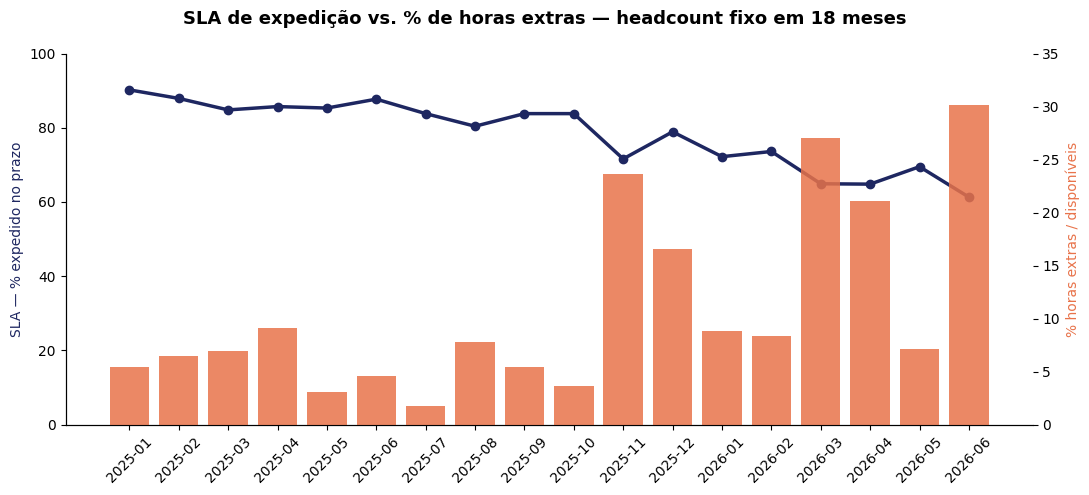

In [16]:
fig, ax1 = plt.subplots(figsize=(11, 5))
x = op_full.mes.astype(str)
ax1.plot(x, op_full.sla, color=NAVY, marker='o', linewidth=2.5, label='% no prazo')
ax1.set_ylabel('SLA — % expedido no prazo', color=NAVY)
ax1.set_ylim(0, 100)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.bar(x, op_full.pct_hora_extra, color=ACCENT, alpha=0.85, label='% hora extra')
ax2.set_ylabel('% horas extras / disponíveis', color=ACCENT)
ax2.set_ylim(0, 35)

fig.suptitle('SLA de expedição vs. % de horas extras — headcount fixo em 18 meses', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()


**Leitura:** o headcount planejado por turno **ficou fixo durante todo o
período** (confirmado acima), enquanto o volume de pedidos cresceu ~35-40%.
Resultado: SLA cai de ~90% para ~61% nos meses de pico, exatamente quando as
horas extras ultrapassam 20-30% das horas disponíveis. **O turno de sábado
extra nunca foi ativado** — é uma alavanca de capacidade existente e não
usada, mais barata do que contratar.


## 4. Bloco 2 — Segmentação: onde está o problema e a oportunidade

### 4.1 Qualidade de cliente por canal de aquisição (B2C)


In [17]:
freq_cliente = conc.groupby('cliente_id').agg(
    n_pedidos=('pedido_id', 'count'),
    receita_bruta=('valor_bruto_produtos', 'sum'),
).reset_index()

cli = clientes.merge(freq_cliente, on='cliente_id', how='left')
cli['n_pedidos'] = cli['n_pedidos'].fillna(0)
cli['recorrente'] = cli['n_pedidos'] > 1

b2c = cli[cli.tipo_cliente == 'B2C']
canal_resumo = b2c.groupby('canal_aquisicao').agg(
    clientes=('cliente_id', 'count'),
    pct_recorrente=('recorrente', 'mean'),
    receita_media=('receita_bruta', 'mean'),
    pedidos_medio=('n_pedidos', 'mean'),
).reset_index().sort_values('pct_recorrente', ascending=False)

canal_resumo['pct_recorrente'] = (canal_resumo.pct_recorrente * 100).round(1)
canal_resumo['receita_media'] = canal_resumo.receita_media.round(0)
canal_resumo


,canal_aquisicao,clientes,pct_recorrente,receita_media,pedidos_medio
2,indicação,479,79.1,1419.0,3.440501
4,orgânico,972,77.4,1368.0,3.382716
0,CRM,270,74.8,1368.0,3.429630
1,busca paga,768,67.8,1201.0,2.908854
5,social pago,986,59.6,958.0,2.374239
3,influenciador,557,38.1,707.0,1.667864


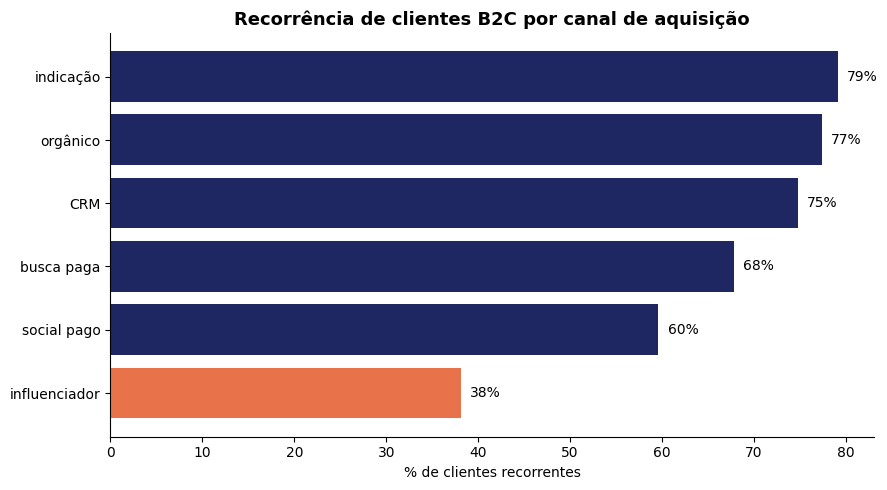

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
ordem = canal_resumo.sort_values('pct_recorrente')
colors = [ACCENT if v < 50 else NAVY for v in ordem.pct_recorrente]
ax.barh(ordem.canal_aquisicao, ordem.pct_recorrente, color=colors)
for i, v in enumerate(ordem.pct_recorrente):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=10)
ax.set_xlabel('% de clientes recorrentes')
ax.set_title('Recorrência de clientes B2C por canal de aquisição', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Leitura:** Indicação, CRM e orgânico entregam 75-79% de recorrência.
Influenciador entrega só 38% — pior canal em qualidade — e é justamente o
que mais recebeu aumento de verba (Seção 3.2). Investir em aquisição sem
olhar qualidade do cliente infla CAC sem construir receita recorrente.


### 4.2 Curva ABC de produtos e alinhamento com estoque

In [19]:
conc_ids = set(conc.pedido_id)
it = itens[itens.pedido_id.isin(conc_ids)].copy()
it['qtd_liq'] = it.quantidade - it.quantidade_cancelada
it['receita_liq'] = it.preco_unitario_bruto * it.qtd_liq - it.desconto_item
it['custo_total'] = it.custo_unitario_tratado * it.qtd_liq
it['margem_contrib'] = it.receita_liq - it.custo_total

prod_ag = it.groupby('produto_id').agg(
    receita_liq=('receita_liq', 'sum'),
    margem_contrib=('margem_contrib', 'sum'),
    qtd_vendida=('qtd_liq', 'sum'),
).reset_index()
prod_ag = prod_ag.merge(produtos[['produto_id','produto','categoria']], on='produto_id', how='left')
prod_ag['margem_pct'] = (prod_ag.margem_contrib / prod_ag.receita_liq * 100).round(1)

prod_ag = prod_ag.sort_values('receita_liq', ascending=False).reset_index(drop=True)
prod_ag['receita_acum_pct'] = prod_ag.receita_liq.cumsum() / prod_ag.receita_liq.sum() * 100
prod_ag['classe_abc'] = prod_ag.receita_acum_pct.apply(lambda p: 'A' if p<=80 else ('B' if p<=95 else 'C'))

print("Distribuição da curva ABC:")
print(prod_ag.groupby('classe_abc').agg(n_produtos=('produto_id','count'),
                                          receita=('receita_liq','sum'),
                                          margem_media_pct=('margem_pct','mean')).round(1))


Distribuição da curva ABC:
            n_produtos    receita  margem_media_pct
classe_abc                                         
A                   36  6862454.5              34.6
B                   47  1296870.2              35.1
C                   97   437133.3              34.8


In [20]:
estoque['valor_estoque'] = estoque.quantidade_disponivel * estoque.custo_medio_unitario
est_ag = estoque.groupby('produto_id').agg(
    estoque_medio_unid=('quantidade_disponivel', 'mean'),
    valor_estoque_medio=('valor_estoque', 'mean'),
    semanas_ruptura=('quantidade_disponivel', lambda x: (x == 0).sum()),
).reset_index()

full = prod_ag.merge(est_ag, on='produto_id', how='left')

resumo_abc = full.groupby('classe_abc').agg(
    n_produtos=('produto_id', 'count'),
    valor_estoque_parado=('valor_estoque_medio', 'sum'),
    semanas_ruptura_media=('semanas_ruptura', 'mean'),
).round(1)
resumo_abc


,n_produtos,valor_estoque_parado,semanas_ruptura_media
classe_abc,,,
A,36,465682.7,6.3
B,47,207635.1,0.2
C,97,76215.9,0.0


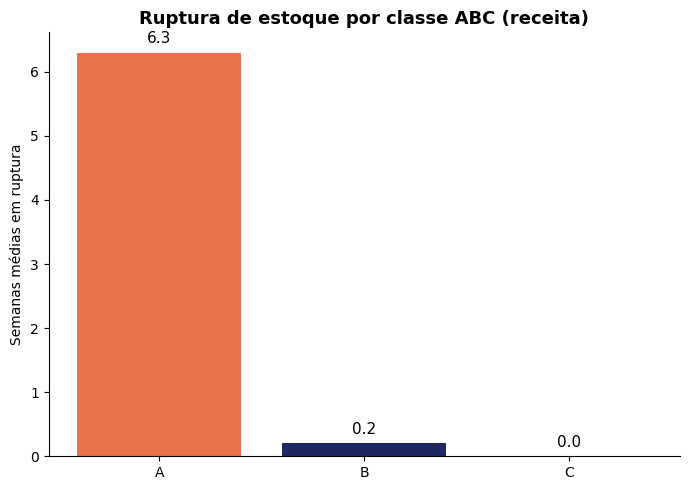

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(resumo_abc.index, resumo_abc.semanas_ruptura_media, color=[ACCENT, NAVY, NAVY])
for i, v in enumerate(resumo_abc.semanas_ruptura_media):
    ax.text(i, v + 0.15, f'{v:.1f}', ha='center', fontsize=11)
ax.set_ylabel('Semanas médias em ruptura')
ax.set_title('Ruptura de estoque por classe ABC (receita)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Leitura:** produtos classe A (80% da receita) ficam em ruptura **6,3
semanas em média** — venda perdida direta. Produtos classe B têm mais de
R$200 mil em capital parado, giro baixo, e **zero semanas em ruptura** —
estão sempre abastecidos porque não vendem o suficiente para faltar. Como a
margem % é parecida entre as classes, **o problema não é o produto, é a
política de compra**: sobra capital nos itens que não precisam e falta nos
que vendem.


## 5. Bloco 3 — Fonte pública: câmbio (BACEN) como apoio à leitura de custo

**Fonte:** Banco Central do Brasil — Sistema Gerenciador de Séries Temporais
(SGS), série 1 — Taxa de câmbio livre, dólar americano (venda), diária.

**Por que essa fonte:** 32 dos 180 produtos são importados, com compra em
USD. A PTAX oficial permite (a) preencher o único registro de câmbio
realmente faltante em `compras.csv` (Seção 2.4) com o dado oficial do dia, e
(b) medir o spread cambial praticado pela empresa vs. a taxa oficial —
separando, no custo de compra importada, o que é câmbio de mercado do que é
negociação com fornecedor.

O código completo de integração está em `integracao_bacen_cambio.py`
(entregável #3). Este ambiente de notebook não tem acesso de rede ao BACEN,
então reproduzimos aqui a lógica de tratamento — para rodar com a chamada
real à API, use o script `.py` separado.


In [22]:
import requests

URL_SGS = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.1/dados"

def buscar_ptax(data_inicial: str, data_final: str) -> pd.DataFrame:
    """data no formato 'dd/mm/aaaa'. Retorna data (datetime) e ptax_venda (float)."""
    params = {"formato": "json", "dataInicial": data_inicial, "dataFinal": data_final}
    resp = requests.get(URL_SGS, params=params, timeout=30)
    resp.raise_for_status()
    df = pd.DataFrame(resp.json())
    df["data"] = pd.to_datetime(df["data"], format="%d/%m/%Y")
    df["ptax_venda"] = df["valor"].astype(float)
    return df[["data", "ptax_venda"]].sort_values("data").reset_index(drop=True)

try:
    ptax = buscar_ptax("01/01/2025", "31/07/2026")
    print(ptax.tail())
except Exception as e:
    print("Sem acesso à rede do BACEN neste ambiente (esperado no sandbox).")
    print("Rodar integracao_bacen_cambio.py localmente para o resultado real.")
    print(f"Detalhe: {e}")


Sem acesso à rede do BACEN neste ambiente (esperado no sandbox).
Rodar integracao_bacen_cambio.py localmente para o resultado real.
Detalhe: 403 Client Error: Forbidden for url: https://api.bcb.gov.br/dados/serie/bcdata.sgs.1/dados?formato=json&dataInicial=01%2F01%2F2025&dataFinal=31%2F07%2F2026


In [23]:
# Merge asof (as documentado no script separado) — reaproveitado aqui como referência de lógica
def enriquecer_compras_com_ptax(compras_df: pd.DataFrame, ptax_df: pd.DataFrame) -> pd.DataFrame:
    ptax_sorted = ptax_df.sort_values("data")
    com_evento = compras_df[compras_df["data_evento_cambio"].notna()].sort_values("data_evento_cambio").copy()
    sem_evento = compras_df[compras_df["data_evento_cambio"].isna()].sort_values("data_pedido_compra").copy()

    com_evento = pd.merge_asof(com_evento, ptax_sorted, left_on="data_evento_cambio", right_on="data", direction="backward")
    sem_evento = pd.merge_asof(sem_evento, ptax_sorted, left_on="data_pedido_compra", right_on="data", direction="backward")

    enriquecido = pd.concat([com_evento, sem_evento], ignore_index=True)
    mask_fill = enriquecido["taxa_cambio_interna"].isna() & (enriquecido["origem_fornecedor"] == "IMPORTADO")
    enriquecido["taxa_cambio_interna_tratada"] = enriquecido["taxa_cambio_interna"].where(~mask_fill, enriquecido["ptax_venda"])
    enriquecido["spread_cambial_pct"] = (enriquecido["taxa_cambio_interna"] - enriquecido["ptax_venda"]) / enriquecido["ptax_venda"] * 100
    return enriquecido

print("Função definida — usar com a série PTAX real (buscar_ptax) em ambiente com acesso à internet.")


Função definida — usar com a série PTAX real (buscar_ptax) em ambiente com acesso à internet.


## 6. Síntese e recomendações

| # | Recomendação | Evidência (seção) |
|---|---|---|
| 1 | Realocar verba de aquisição — reduzir Influenciador, redirecionar para orgânico/CRM/indicação | 3.2, 4.1 |
| 2 | Corrigir a política de compra por classe ABC — priorizar disponibilidade da classe A | 4.2 |
| 3 | Ativar turno de sábado extra nos picos antes de acelerar mais aquisição | 3.3 |
| 4 | Revisar critério de desconto e frete por canal/segmento de cliente | 3.1, 4.1 |

**Limitações declaradas:**
- Margem de contribuição calculada por item (preço − desconto − custo), sem rateio de frete/comissão por produto.
- 248 itens (92 produtos) usam custo_atual como aproximação do custo histórico.
- Giro de estoque é uma proxy (vendas totais no período / estoque médio), não um cálculo de giro por janela móvel.
- Câmbio: apenas 1 registro de compra importada precisou de tratamento via PTAX; o restante dos nulos é comportamento esperado (compras nacionais).

**Plano de trabalho — próximos passos:**
1. Validar as recomendações com Marketing, Comercial e Operação.
2. Definir metas por canal de aquisição com recorrência mínima, não só CAC.
3. Redesenhar a política de compra por classe ABC e reavaliar SLA de fornecedores importados.
4. Rodar piloto de sábado extra em 1-2 picos sazonais e medir impacto no SLA.
5. Acompanhar mensalmente, no mesmo painel: desconto %, CAC, SLA e ruptura da classe A.
